# ECE1508: Deep Generative Models -- Summer 2026
## Assignment 3: Generative Adversarial Networks
## Question 3: GAN vs WGAN on MNIST

In this assignment, we train a vanilla GAN and WGAN on a small subset of MNIST containing only three digits. The goal is to compare numerical stability of vanilla GAN against WGAN.


### Loading Modules
Let's load some required modules.

In [1]:
import random
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, TensorDataset
from torchvision import transforms
from torchvision.datasets import MNIST
from torchvision.utils import make_grid

# pandas for easier sampling code
import pandas as pd 


# Device
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print('Device:', device)


Device: mps



### Loading Dataset
We use digits `0`, `1`, and `2` to keep the experiment simple.


In [2]:
# Sample 1000 samples of each digit
def load_three_digit_mnist(root='./data', digits=(0, 1, 2), max_per_digit=1000, train=True):
    transform = transforms.ToTensor()
    dataset = MNIST(root=root, train=train, download=True, transform=transform)
    targets = dataset.targets

    # 1) with pandas
    labels = pd.Series(targets.numpy()) # 1D tensor -> Series
    labels = labels[labels.isin(digits)]
    sampled = labels.groupby(labels).sample(n=max_per_digit, random_state=0)

    indices = torch.tensor(sampled.index.values, dtype=torch.long)

    # 2) without pandas 
    # mask = torch.zeros_like(targets, dtype=torch.bool)
    
    # g = torch.Generator().manual_seed(0)
    
    # for d in digits:
    #     mask_d = (targets == d) # (len(targets),) with boolean values 
    #     idx = torch.where(mask_d)[0] # use [0] to unwrap (tuple -> tensor), e.g., (tensor([3, 9, 11]),) -> tensor([3, 9, 11])
    #     perm = torch.randperm(len(idx), generator=g)
    #     shuffled = idx[perm] # reorder idx into e.g., tensor([3, 9, 11]) -> tensor([11, 3, 9])
    #     selected = shuffled[:max_per_digit]
    #     mask[selected] = True

    # indices = mask.nonzero(as_tuple=True)[0]

    return Subset(dataset, indices)



train_dataset = load_three_digit_mnist(train=True, max_per_digit=1000)


# Count labels in the subset
train_labels = []
for item in train_dataset:
    train_labels.append(int(item[1]))
print('Train label counts:', Counter(train_labels))

Train label counts: Counter({0: 1000, 1: 1000, 2: 1000})



#### Data Loaders

Let's take a look at a few samples. 


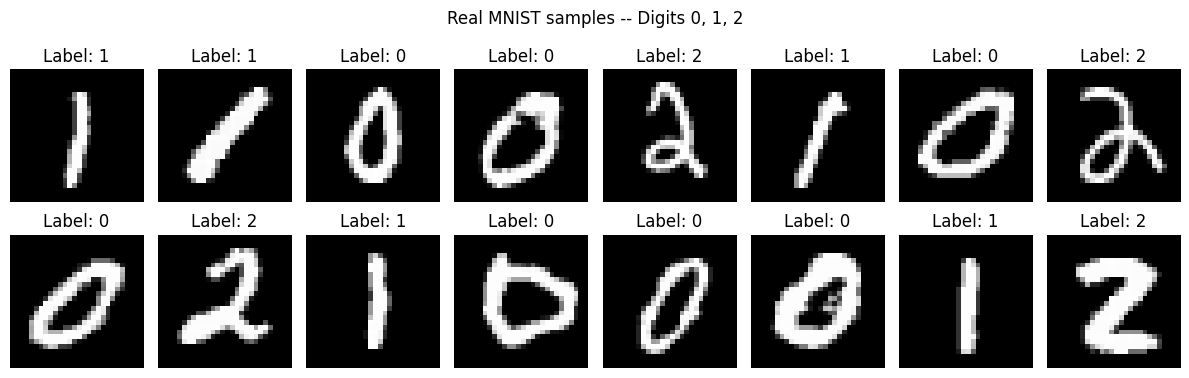

In [3]:
# batch size 
batch_size = 128

# build the loader
train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    drop_last=True # drop last batch because it can be smaller than batch_size
)

# Visualize a few real samples
fig, axes = plt.subplots(2, 8, figsize=(12, 4))

# train_dataset is sorted due to groupby
# to get random samples for vis, we'll use train loader 
images, labels = next(iter(train_loader)) 

for ax, img, label in zip(axes.flatten(), images[:16], labels[:16]):
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'Label: {label.item()}')
    ax.axis('off')

plt.suptitle('Real MNIST samples -- Digits 0, 1, 2')
plt.tight_layout()
plt.show()


### Models (vanilla GAN)
We next implement the generator and discriminator. Clearly, the data in this case is of size $28 \times 28$. We consider a latent space of size $m=64$. 

#### Discriminator
The discriminator is to get a $28 \times 28$ input $x$ and classify it as `real` or `fake`. We consider the following MLP:
$$
\mathrm{Linear} (784 \rightarrow 128) + \mathrm{LeakyReLU}\\
\downarrow\\
\mathrm{Linear} (128 \rightarrow 128) + \mathrm{LeakyReLU}\\
\downarrow\\
\mathrm{Linear} (128 \rightarrow 128) + \mathrm{LeakyReLU}\\
\downarrow\\
\mathrm{Linear} (128 \rightarrow 1)
$$
For all $\mathrm{LeakyReLU}$ activations set $\texttt{negative\_slope}=0.2$. Note that the last layer should be properly activated for classification.


In [4]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.model(x)


#### Generator

For generator, we need a network which converts a 64-dimensional latent to a $28 \times 28$ MNIST image. For this, we implement the following MLP:
$$
\mathrm{Linear} (64 \rightarrow 128) + \mathrm{ReLU}\\
\downarrow\\
\mathrm{Linear} (128 \rightarrow 128) + \mathrm{ReLU}\\
\downarrow\\
\mathrm{Linear} (128 \rightarrow 128) + \mathrm{ReLU}\\
\downarrow\\
\mathrm{Linear} (128 \rightarrow 784) + \mathrm{Sigmoid}
$$


In [5]:

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Sigmoid() # Ensure output is in [0, 1] range
        )

    def forward(self, z):
        return self.model(z)


#### Sampling the Generator

We finally write a function to sample the generator.


In [6]:
# Sample latent
def sample_noise(n, device):
    return torch.randn(n, 64, device=device)


# Pass it through the generator
def show_generated_images(generator, title='Generated samples', n=16):
    generator.eval()
    with torch.no_grad():
        z = sample_noise(n, device)
        generated_images = generator(z).view(n, 1, 28, 28).cpu()

    fig, axes = plt.subplots(2, 8, figsize=(12, 4))
    for ax, img in zip(axes.flatten(), generated_images):
        ax.imshow(img.squeeze(), cmap='gray')
        ax.axis('off')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()



Let's initiate a random generator and look at its samples before training.

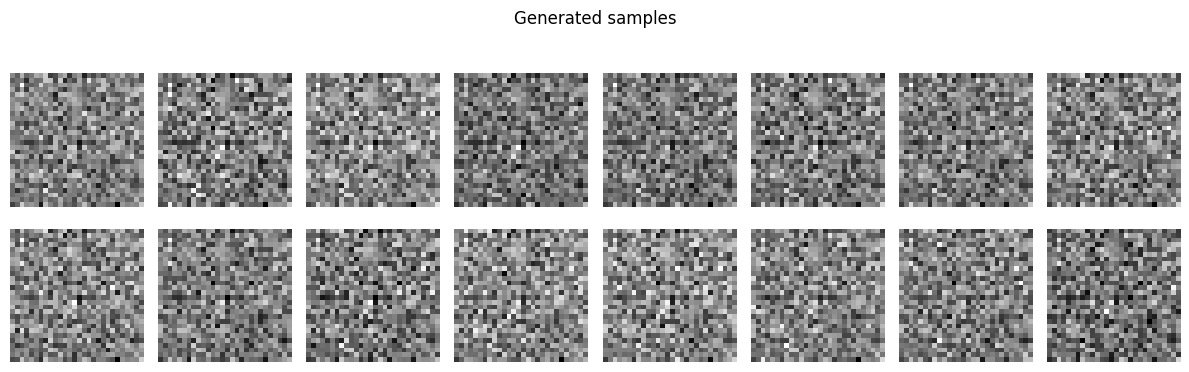

In [7]:
G = Generator().to(device)
show_generated_images(G, title='Generated samples', n=16)



### Training via Vanilla GAN Loop

We now train this model as we did for Swiss Roll dataset, i.e., with the vanilla GAN. 


In [8]:
def train_GAN_vanilla(n_inner = 6, epochs = 100):
    # define right loss
    criterion = nn.BCEWithLogitsLoss()
    
    # instantiate G and D
    G = Generator().to(device)
    D = Discriminator().to(device)

    # Set the optimizers
    lr_D = 2e-3
    lr_G = 2e-4
    opt_G = torch.optim.Adam(G.parameters(), lr=lr_G, betas=(0.5, 0.999))
    opt_D = torch.optim.Adam(D.parameters(), lr=lr_D, betas=(0.5, 0.999))

    history = {
        'd_loss': [],
        'g_loss': [],
        'd_real': [],
        'd_fake': [],
    }

    # Start the loop
    for epoch in range(1, epochs + 1):
        G.train()
        D.train()

        d_loss_epoch = 0.0
        g_loss_epoch = 0.0
        d_real_epoch = 0.0
        d_fake_epoch = 0.0
        num_batches = 0

        for x_real, _ in train_loader:
            x_real = x_real.to(device)
            batch_size = x_real.size(0)
            real_labels = torch.ones(batch_size, 1, device=device)
            fake_labels = torch.zeros(batch_size, 1, device=device)

            # inner loop for discriminator
            for _ in range(n_inner):
                opt_D.zero_grad()
                d_out_real = D(x_real)
                loss_d_real = criterion(d_out_real, real_labels)

                z = sample_noise(batch_size, device)
                x_fake = G(z).detach()
                d_out_fake = D(x_fake)
                loss_d_fake = criterion(d_out_fake, fake_labels)

                loss_d = loss_d_real + loss_d_fake
                loss_d.backward()
                opt_D.step()


            # Update the generator
            opt_G.zero_grad()
            z = sample_noise(batch_size, device)
            x_fake = G(z)
            d_out_fake = D(x_fake)
            loss_g = criterion(d_out_fake, real_labels)
            loss_g.backward()
            opt_G.step()


            with torch.no_grad():
                d_real_prob = torch.sigmoid(D(x_real)).mean().item()
                d_fake_prob = torch.sigmoid(D(x_fake)).mean().item()

            d_loss_epoch += loss_d.item()
            g_loss_epoch += loss_g.item()
            d_real_epoch += d_real_prob
            d_fake_epoch += d_fake_prob
            num_batches += 1


        # Update history
        history['d_loss'].append(d_loss_epoch / num_batches)
        history['g_loss'].append(g_loss_epoch / num_batches)
        history['d_real'].append(d_real_epoch / num_batches)
        history['d_fake'].append(d_fake_epoch / num_batches)


        if epoch == 1 or epoch % 20 == 0:
            print(f'Epoch {epoch:03d}/{epochs} | D loss: {history["d_loss"][-1]:.4f} | G loss: {history["g_loss"][-1]:.4f} | D(real): {history["d_real"][-1]:.3f} | D(fake): {history["d_fake"][-1]:.3f}')
            
    return G, history


#### Experiments with Vanilla GAN

Let's now train the model and look at its output samples.


Epoch 001/100 | D loss: 0.0094 | G loss: 10.2462 | D(real): 0.997 | D(fake): 0.000
Epoch 020/100 | D loss: 0.1462 | G loss: 12.8593 | D(real): 0.998 | D(fake): 0.005
Epoch 040/100 | D loss: 0.0008 | G loss: 11.4634 | D(real): 1.000 | D(fake): 0.000
Epoch 060/100 | D loss: 0.0004 | G loss: 9.6042 | D(real): 1.000 | D(fake): 0.000
Epoch 080/100 | D loss: 0.0064 | G loss: 7.5659 | D(real): 0.999 | D(fake): 0.001
Epoch 100/100 | D loss: 0.0018 | G loss: 7.6647 | D(real): 1.000 | D(fake): 0.001


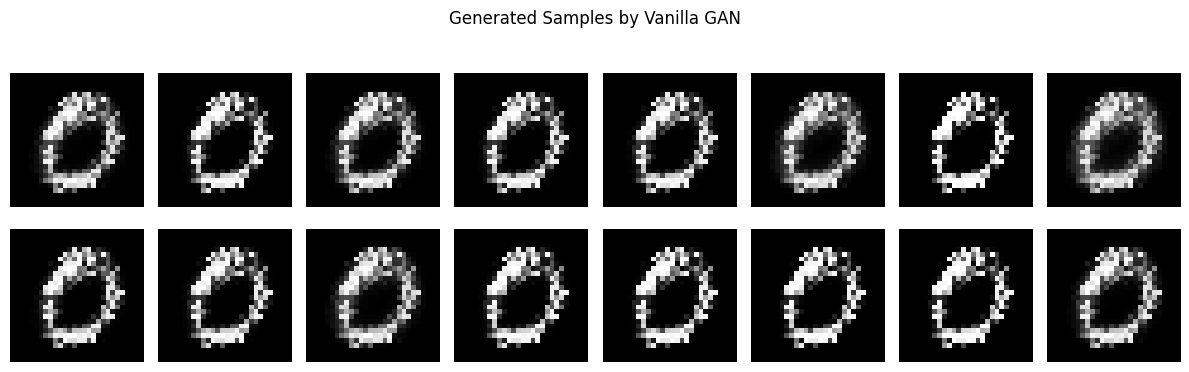

In [9]:
# Train
G, history = train_GAN_vanilla()

# Sample the trained model
show_generated_images(G, title='Generated Samples by Vanilla GAN')

## Question: _What do you observation?Do a quick research to understand what this behavior is called._
All 16 generated samples shown above are 0s, despite each one being generated from a different, independently sampled noise vector. This is a well-known failure mode of vanilla GANs called **mode collapse**: the generator discovers a single output (or a narrow region of outputs) that reliably fools the discriminator, and rather than continuing to explore the rest of the data distribution, it maps most or all latent codes to that same output.

#### Training Dynamics of Vanilla GAN
Let's look at the losses

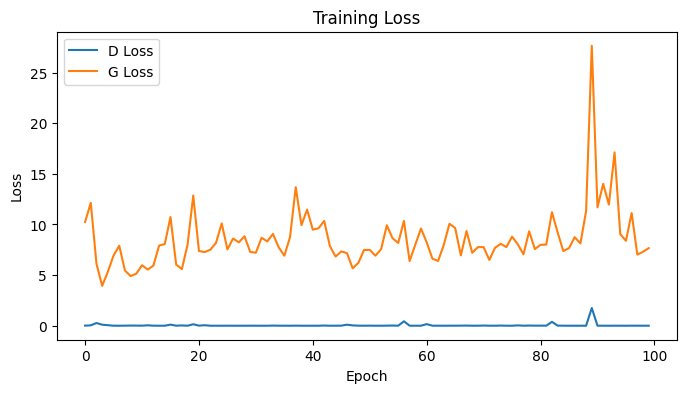

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(history['d_loss'], label='D Loss')
plt.plot(history['g_loss'], label='G Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.show()

## Question: _Does the loss curve tell you anything in support of your earlier observation?_
The discriminator loss is almost flat near 0, whereas the generator loss fluctuates but stays at a roughly similar level throughout the 100 epochs, with no downward trend. Neither loss shows a clear trend, meaning training never approached the adversarial equilibrium where D and G improve together; instead D wins early and stays confident, and the near-zero D loss means the gradient signal passed back to G is vanishingly small, leaving G unable to keep improving. This is consistent with the observation above and the description of mode collapse, where the generator only needs to keep fooling an already-saturated discriminator with the one output it has found, rather than being pushed to explore the rest of the data distribution.

### Confidence of Vanilla GAN
Let's look at the confidence at discriminator.

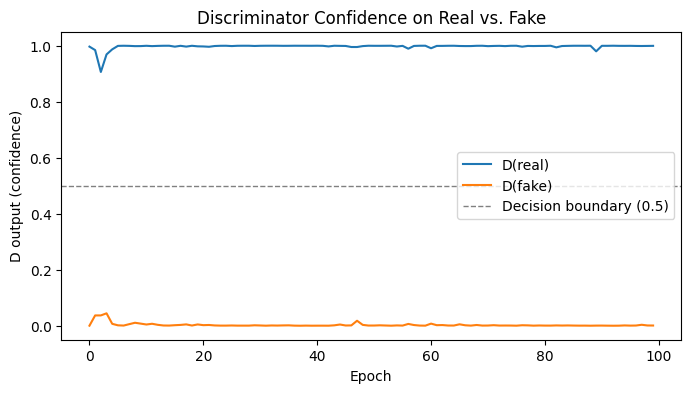

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(history['d_real'], label='D(real)')
plt.plot(history['d_fake'], label='D(fake)')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Decision boundary (0.5)')
plt.xlabel('Epoch')
plt.ylabel('D output (confidence)')
plt.title('Discriminator Confidence on Real vs. Fake')
plt.legend()
plt.show()

## Question: _What does the confidence curve say in support of your earlier observation?_
In terms of the discriminator's confidence, D(real) stays near 100% and D(fake) stays near 0% for essentially the entire 100 epochs, with no narrowing of the gap and no fluctuation over time. This is consistent with mode collapse: the discriminator can consistently distinguish the generator's single collapsed output from real samples, and the fact that this gap never changes suggests the generator settled onto that one output early and never explored alternatives afterward, rather than oscillating between different (and occasionally more convincing) outputs.

### Training via WGAN Loop
We now modify the training loop for WGAN apprach. Note that we do not need to change the generator or discriminator. It's enough to drop the final activation of the discriminator. 

__Lipschitz Continuity:__ To guarantee Lipschitz continuity of the discriminator, we use weight clipping. To this end, after each update of discriminator parameters, we clip them as
$$ \phi \gets \mathrm{Clip}(\phi, 0.01) = 
\begin{cases}
\phi_i &\vert \phi_i \vert \leq 0.01\\
\mathrm{sign}(\phi_i) 0.01 &\vert \phi_i \vert > 0.01
\end{cases}
$$
To apply this clipping, we could directly use the method `.data.clamp_(-clip_value, clip_value)` with `clip_value = 0.01`.


#### Modifying Train Loop
Modify the train loop to implement WGAN training. 

In [12]:
def train_WGAN(n_inner = 6, epochs = 100):
    # instantiate G and D
    ## COMPLETE ## You may copy your previous training loop and modify it directly here
    G = Generator().to(device)
    D = Discriminator().to(device)

    # Set the optimizers
    lr_D = 2e-3
    lr_G = 2e-4
    opt_G = torch.optim.Adam(G.parameters(), lr=lr_G, betas=(0.5, 0.999))
    opt_D = torch.optim.Adam(D.parameters(), lr=lr_D, betas=(0.5, 0.999))

    clip_value = 0.01  

    history = {
        'd_loss': [],
        'g_loss': [],
        'd_real': [],
        'd_fake': [],
    }

    for epoch in range(1, epochs + 1):
        G.train()
        D.train()

        d_loss_epoch = 0.0
        g_loss_epoch = 0.0
        d_real_epoch = 0.0
        d_fake_epoch = 0.0
        num_batches = 0

        for x_real, _ in train_loader:
            x_real = x_real.to(device)
            batch_size = x_real.size(0)

            # inner loop for the critic
            for _ in range(n_inner):
                opt_D.zero_grad()
                d_out_real = D(x_real)

                z = sample_noise(batch_size, device)
                x_fake = G(z).detach()
                d_out_fake = D(x_fake)

                loss_d = -(torch.mean(d_out_real) - torch.mean(d_out_fake))
                loss_d.backward()
                opt_D.step()

                # enforce K-Lipschitz constraint
                for p in D.parameters():
                    p.data.clamp_(-clip_value, clip_value)

            # Update the generator
            opt_G.zero_grad()
            z = sample_noise(batch_size, device)
            x_fake = G(z)
            d_out_fake = D(x_fake)
            loss_g = -torch.mean(d_out_fake)
            loss_g.backward()
            opt_G.step()

            with torch.no_grad():
                d_real_score = D(x_real).mean().item()
                d_fake_score = D(x_fake).mean().item()

            d_loss_epoch += loss_d.item()
            g_loss_epoch += loss_g.item()
            d_real_epoch += d_real_score
            d_fake_epoch += d_fake_score
            num_batches += 1

        history['d_loss'].append(d_loss_epoch / num_batches)
        history['g_loss'].append(g_loss_epoch / num_batches)
        history['d_real'].append(d_real_epoch / num_batches)
        history['d_fake'].append(d_fake_epoch / num_batches)


        if epoch == 1 or epoch % 20 == 0:
            print(f'Epoch {epoch:03d}/{epochs} | D loss: {history["d_loss"][-1]:.4f} | G loss: {history["g_loss"][-1]:.4f} | D(real): {history["d_real"][-1]:.3f} | D(fake): {history["d_fake"][-1]:.3f}')
            
    return G, history

#### Experiment with WGAN
Let's now look at samples given by WGAN after training.

Epoch 001/100 | D loss: -1.1474 | G loss: 0.8727 | D(real): 0.285 | D(fake): -0.873
Epoch 020/100 | D loss: -0.1244 | G loss: -0.1026 | D(real): 0.229 | D(fake): 0.103
Epoch 040/100 | D loss: -0.1325 | G loss: 0.0284 | D(real): 0.108 | D(fake): -0.028
Epoch 060/100 | D loss: -0.1186 | G loss: 0.0219 | D(real): 0.098 | D(fake): -0.022
Epoch 080/100 | D loss: -0.1106 | G loss: 0.0202 | D(real): 0.091 | D(fake): -0.020
Epoch 100/100 | D loss: -0.0947 | G loss: 0.0321 | D(real): 0.066 | D(fake): -0.032


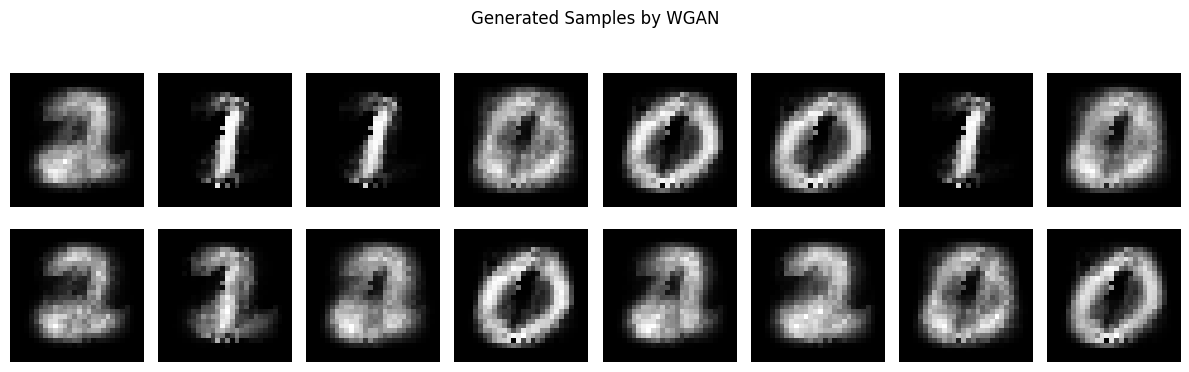

In [13]:
# Train
G, history = train_WGAN()

# Sample the trained model
show_generated_images(G, title='Generated Samples by WGAN')

## Question: _Any change in the previously seen behavior? Explain your observation. What is your conclusion?_
With WGAN, the generated samples now include 1s and 2s in addition to 0s, unlike vanilla GAN, which collapsed entirely onto a single digit. This is consistent with WGAN's smoother, non-vanishing gradient from the Wasserstein loss and weight-clipped critic, which keeps giving the generator a useful learning signal instead of letting it get stuck on one output once the critic becomes confident.  
  
The conclusion is that WGAN reduces, though does not necessarily eliminate, the mode collapse problem seen in vanilla GAN, since the generator continues to explore more of the underlying data distribution during training.

#### Training Dynamics of WGAN
Now look at the training dynamics.

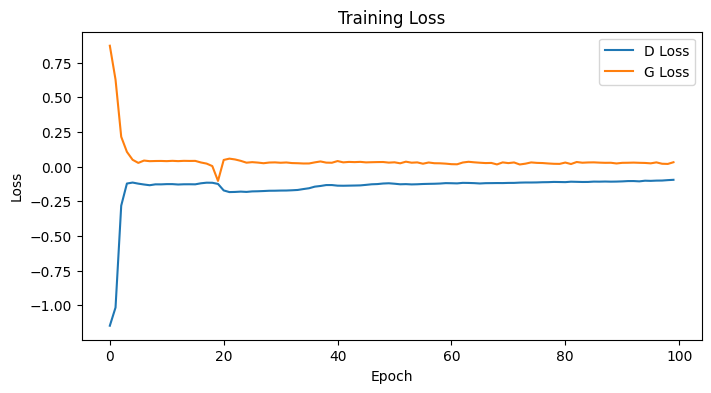

In [14]:
plt.figure(figsize=(8, 4))
plt.plot(history['d_loss'], label='D Loss')
plt.plot(history['g_loss'], label='G Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.show()

## Question: _Does this observation aligns with your conclusion? Explain._
This aligns with our conclusion. WGAN's loss curves stay stable instead of collapsing to an extreme, which shows the generator kept getting a real gradient signal throughout training. That's the same mechanism we pointed to earlier for why WGAN reduces mode collapse. 